# 2.20 Final

> Let us consider $\boldsymbol{b}_1, \boldsymbol{b}_2, \boldsymbol{b}'_1, \boldsymbol{b}'_2$ four vectors of $\mathbb{R}^2$ expressed in the standard basis of $\mathbb{R}^2$ as:

$$
\begin{aligned}
    \boldsymbol{b}_1 &= \begin{bmatrix}
        2 \\ 1\\ 
    \end{bmatrix}
    &
    \boldsymbol{b}_2 &= \begin{bmatrix}
        -1 \\ -1\\ 
    \end{bmatrix}
    &
    \boldsymbol{b'}_1 &= \begin{bmatrix}
        2 \\ -2\\ 
    \end{bmatrix}
    &
    \boldsymbol{b'}_2 &= \begin{bmatrix}
        1 \\ 1\\ 
    \end{bmatrix}
\end{aligned}
$$

> and let us define two ordered bases $B = (\boldsymbol{b}_1, \boldsymbol{b}_2)$ and $B' = (\boldsymbol{b}'_1, \boldsymbol{b}'_2)$ of $\mathbb{R}^2$.

> (a) Show that $B$ and $B'$ are two bases of $\mathbb{R}^2$ and draw those basis vectors.

Check if $\boldsymbol{b}_1, \boldsymbol{b}_2$ are linearly independent:

$$
    \begin{bmatrix}
        2 & -1\\
        1 & -1\\
    \end{bmatrix}
    \leadsto
    \begin{bmatrix}
        1 & 0\\
        0 & 1\\
    \end{bmatrix}
$$

Check if $\boldsymbol{b}'_1, \boldsymbol{b}'_2$ are linearly independent:

$$
    \begin{bmatrix}
        2 & 1\\
        -2 & 1\\
    \end{bmatrix}
    \leadsto
    \begin{bmatrix}
        1 & 0\\
        0 & 1\\
    \end{bmatrix}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

b_1 = np.array([2, 1])
b_2 = np.array([-1, -1])

bb_1 = np.array([2, -2])
bb_2 = np.array([1, 1])

def plot_bases(x_1, x_2):
    plt.plot([0, x_1[0]], [0, x_1[1]])
    plt.plot([0, x_2[0]], [0, x_2[1]])
    plt.axvline(x=0, color="k")
    plt.axhline(y=0, color="k")

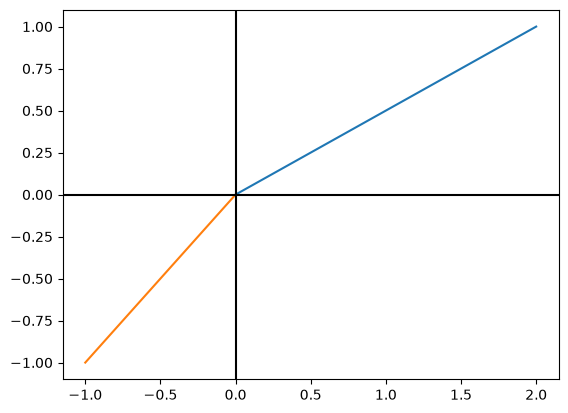

In [14]:
plot_bases(b_1, b_2)

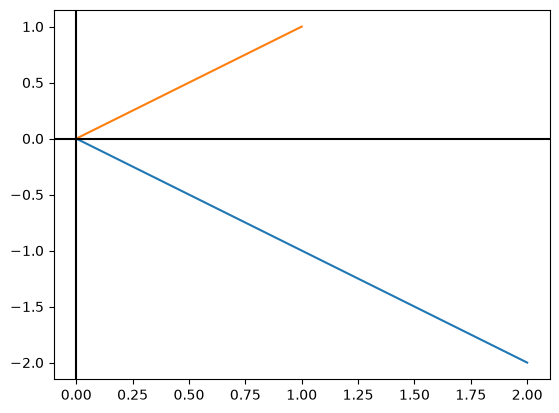

In [15]:
plot_bases(bb_1, bb_2)

> (b) Compute the matrix $\boldsymbol{P}_1$, that performs a basis change from $B'$ to $B$.

The transformation matrix is given by:

$$
    P_1 = T^{-1} A_{\Phi} S
$$

where $S$ maps from $B'$ to the standard basis of $\mathbb{R}^2$, $A_\Phi$ is the identity transform matrix $I$, and $T$ maps from the standard basis to $B$.

$$
    S = \begin{bmatrix}
        2 & 1\\
        -2 & 1\\
    \end{bmatrix}
$$

$$
    T = \begin{bmatrix}
        2 & -1\\
        1 & -1\\
    \end{bmatrix}
$$

Compute the inverse:

$$
    \left[\begin{array}{cc|cc}
        2 & -1 & 1 & 0\\
        1 & -1 & 0 & 1\\
    \end{array}\right]
    \leadsto
    \left[\begin{array}{cc|cc}
        1 & 0 & 1 & -1\\
        0 & 1 & 1 & -2\\
    \end{array}\right]
$$

$$
    T^{-1} = 
    \begin{bmatrix}
        1 & -1\\
        1 & -2\\
    \end{bmatrix}
$$

$$
    P_1 = \begin{bmatrix}
        4 & 0 \\
        6 & -1 \\
    \end{bmatrix}
$$

In [9]:
S = np.column_stack([bb_1, bb_2])
T = np.column_stack([b_1, b_2])

In [11]:
T_inv = np.linalg.inv(T)
T_inv

array([[ 1., -1.],
       [ 1., -2.]])

In [14]:
P_1 = T_inv @ S
P_1

array([[ 4.,  0.],
       [ 6., -1.]])

In [21]:
x_bb = np.array([1, 5])
x_r3 = S @ x_bb
x_b = P_1 @ x_bb

print(f"Point {x_r3} in Basis B': {x_bb}")
print(f"After transform to Basis B: {x_b}")
print(f"Back to R^3: {T @ x_b}")

Point [7 3] in Basis B': [1 5]
After transform to Basis B: [4. 1.]
Back to R^3: [7. 3.]


> (c) We consider $c_1, c_2, c_3$ 3 vectors of $\mathbb{R}^3$ defined in the standard basis of $\mathbb{R}$ as:

$$
\begin{aligned}
    \boldsymbol{c}_1 &= \begin{bmatrix}
        1 \\ 2\\ -1 \\
    \end{bmatrix}
    &
    \boldsymbol{c}_2 &= \begin{bmatrix}
        0 \\ -1\\ 2\\
    \end{bmatrix}
    &
    \boldsymbol{c}_3 &= \begin{bmatrix}
        1 \\ 0\\ -1\\
    \end{bmatrix}
    \end{aligned}
$$

and we define $C = (\boldsymbol{c}_1, \boldsymbol{c}_2, \boldsymbol{c}_3)$.

> 1. Show that $C$ is a basis of $\mathbb{R}^3$, e.g., by using determinants.

To show that $C$ is a basis of $\mathbb{R}^3$, we need to show that the basis vectors are linearly independent.
If all basis vectors are linearly independent, the matrix of basis vectors has full rank.
And a matrix $A$ has full rank, iff the determinant $\det(A) \neq 0$.

We will use the *Sarrus' rule* to compute the derminant:

$$
    \begin{aligned}
        \det(C) &= 1 * -1 * -1 \\
        &+ 0 * 0 * -1 \\
        &+ 1 * 2 * 2 \\
        &- (1 * -1 * -1) \\
        &- 1 * 0 * 2  \\
        &- 0 * 2 * -1\\
        &= 4
    \end{aligned}
$$

In [2]:
import numpy as np
C = np.array([
    [1, 2, -1],
    [0, -1, 2],
    [1, 0, -1]
]).T

np.linalg.det(C)

np.float64(3.999999999999999)

> 2. Let us call $C' = (\boldsymbol{c}'_1, \boldsymbol{c}'_2, \boldsymbol{c}'_3)$ the standard basis of $\mathbb{R}^3$. Determine the matrix $\boldsymbol{P}_2$ that performs the basis change from $C$ to $C'$.

$$
    \boldsymbol{P}_1 = \begin{bmatrix}
        1 & 0 & 1\\
        2 & -1 & 0\\
        -1 & 2 & -1\\
    \end{bmatrix}
$$